/home/sudharshan/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.1
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA GeForce RTX 4070" (12 GiB, sm_89, mempool enabled)
   Kernel cache:
     /home/sudharshan/.cache/warp/1.12.0
Total nodes: 32  (stem: 12, leaf: 20)
Module __main__ 2d52ec0 load on device 'cuda:0' took 335.34 ms  (compiled)


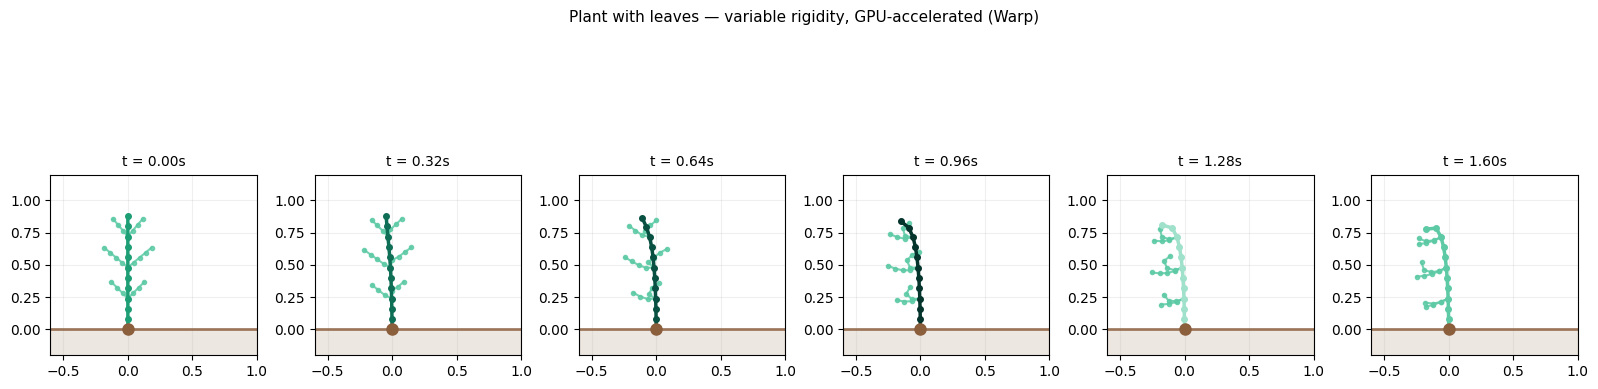

Saved plant_with_leaves.png


In [1]:
import warp as wp
import numpy as np
import matplotlib.pyplot as plt

wp.init()

# ── GPU kernel: same as before, handles ALL nodes (stem + leaf nodes) ──
@wp.kernel
def apply_forces(
    positions:  wp.array(dtype=wp.vec3),
    velocities: wp.array(dtype=wp.vec3),
    is_root:    wp.array(dtype=wp.int32),  # 1 = fixed, 0 = free
    dt: float
):
    i = wp.tid()
    if is_root[i] == 1:
        return  # root nodes stay fixed

    wind    = wp.vec3(1.2,  0.0, 0.0)
    gravity = wp.vec3(0.0, -0.4, 0.0)
    damping = float(0.94)
    velocities[i] = (velocities[i] + (gravity + wind) * dt) * damping
    positions[i]  =  positions[i]  + velocities[i] * dt


def enforce_constraints_cpu(pos_np, vel_np, edges, stiffness_map, n_total):
    """
    edges = list of (parent_idx, child_idx, rest_length)
    stiffness_map = per-node stiffness value
    Works for both stem nodes AND leaf nodes.
    """
    # Step 1 — enforce distance constraints along all edges
    for (parent_idx, child_idx, rest_len) in edges:
        parent = pos_np[parent_idx]
        child  = pos_np[child_idx]
        diff   = child - parent
        dist   = np.linalg.norm(diff)
        if dist > 1e-6:
            unit = diff / dist
            pos_np[child_idx] = parent + unit * rest_len

    # Step 2 — rigidity pull: each node pulled toward parent direction
    for (parent_idx, child_idx, rest_len) in edges:
        stiffness = stiffness_map[child_idx]
        parent    = pos_np[parent_idx]
        ideal_x   = parent[0]          # vertical axis = same X as parent
        actual_x  = pos_np[child_idx][0]
        pos_np[child_idx][0] = actual_x + (ideal_x - actual_x) * stiffness

    # Step 3 — ground clamp
    for i in range(n_total):
        if pos_np[i][1] < 0.0:
            pos_np[i][1] = 0.0
            vel_np[i][1] = 0.0

    return pos_np, vel_np


# ── Build plant structure ──────────────────────────────────────────────
STEM_NODES   = 12
REST_LENGTH  = 0.08

# Leaf configuration: (attach_to_stem_node, angle_degrees, n_leaf_nodes)
LEAF_CONFIG = [
    (3,  45, 3),   # leaf at stem node 3,  angled 45° right
    (3, -45, 3),   # leaf at stem node 3,  angled 45° left
    (6,  50, 4),   # leaf at stem node 6,  angled 50° right
    (6, -50, 4),   # leaf at stem node 6,  angled 50° left
    (9,  40, 3),   # leaf at stem node 9,  angled 40° right
    (9, -40, 3),   # leaf at stem node 9,  angled 40° left
]
LEAF_REST = 0.06   # leaf segments slightly shorter than stem

# Build positions, edges, stiffness values
positions  = []
is_root    = []
edges      = []
stiffness  = []

# ── Stem nodes ──
for i in range(STEM_NODES):
    positions.append([0.0, i * REST_LENGTH, 0.0])
    is_root.append(1 if i == 0 else 0)
    t = i / (STEM_NODES - 1)
    stiffness.append(0.92 * (1 - t) + 0.05 * t)  # stiff base, flexible tip
    if i > 0:
        edges.append((i - 1, i, REST_LENGTH))

# ── Leaf nodes ──
for (attach_node, angle_deg, n_leaf) in LEAF_CONFIG:
    angle_rad = np.radians(angle_deg)
    # Leaf grows in direction (sin(angle), cos(angle)) from attachment point
    dx = np.sin(angle_rad) * LEAF_REST
    dy = np.cos(angle_rad) * LEAF_REST

    prev_idx = attach_node   # leaf starts from the stem node
    base_pos = positions[attach_node]

    for j in range(1, n_leaf + 1):
        new_pos = [
            base_pos[0] + dx * j,
            base_pos[1] + dy * j,
            0.0
        ]
        new_idx = len(positions)
        positions.append(new_pos)
        is_root.append(0)            # leaf nodes are all free
        # Leaves are MORE flexible than stem tip (they flutter easily)
        leaf_t = j / n_leaf
        stiffness.append(0.04 * (1 - leaf_t) + 0.01 * leaf_t)
        edges.append((prev_idx, new_idx, LEAF_REST))
        prev_idx = new_idx

# Convert to numpy arrays
pos_np  = np.array(positions,  dtype=np.float32)
vel_np  = np.zeros_like(pos_np)
root_np = np.array(is_root,    dtype=np.int32)
n_total = len(positions)

print(f"Total nodes: {n_total}  "
      f"(stem: {STEM_NODES}, leaf: {n_total - STEM_NODES})")

# ── Simulation loop ────────────────────────────────────────────────────
frames = []
for frame in range(120):
    pos_gpu  = wp.array(pos_np,  dtype=wp.vec3, device="cuda")
    vel_gpu  = wp.array(vel_np,  dtype=wp.vec3, device="cuda")
    root_gpu = wp.array(root_np, dtype=wp.int32, device="cuda")

    wp.launch(apply_forces, dim=n_total,
              inputs=[pos_gpu, vel_gpu, root_gpu, 0.016])

    pos_np = pos_gpu.numpy().copy()
    vel_np = vel_gpu.numpy().copy()

    # Pin root explicitly
    pos_np[0] = [0.0, 0.0, 0.0]
    vel_np[0] = [0.0, 0.0, 0.0]

    pos_np, vel_np = enforce_constraints_cpu(
        pos_np, vel_np, edges, stiffness, n_total
    )

    if frame % 20 == 0:
        frames.append(pos_np.copy())


# ── Plot ───────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, len(frames), figsize=(16, 5))
stem_color = '#1D9E75'
leaf_color = '#5DCAA5'
colors     = ['#1D9E75', '#0F6E56', '#085041', '#04342C', '#9FE1CB', '#5DCAA5']

for idx, (ax, frame_pos) in enumerate(zip(axes, frames)):
    # Ground
    ax.axhspan(-0.3, 0.0, color='#8B5E3C', alpha=0.15)
    ax.axhline(y=0, color='#8B5E3C', linewidth=2, alpha=0.8)

    # Draw stem
    stem_x = frame_pos[:STEM_NODES, 0]
    stem_y = frame_pos[:STEM_NODES, 1]
    ax.plot(stem_x, stem_y, 'o-',
            color=colors[idx % len(colors)],
            linewidth=2.5, markersize=4, zorder=3)

    # Draw each leaf
    node_cursor = STEM_NODES
    for (attach_node, angle_deg, n_leaf) in LEAF_CONFIG:
        leaf_indices = [attach_node] + list(
            range(node_cursor, node_cursor + n_leaf)
        )
        lx = frame_pos[leaf_indices, 0]
        ly = frame_pos[leaf_indices, 1]
        ax.plot(lx, ly, 'o-',
                color=leaf_color,
                linewidth=1.5, markersize=3,
                alpha=0.85, zorder=2)
        node_cursor += n_leaf

    # Root anchor dot
    ax.plot(frame_pos[0, 0], frame_pos[0, 1],
            'o', color='#8B5E3C', markersize=8, zorder=5)

    ax.set_xlim(-0.6, 1.0)
    ax.set_ylim(-0.2, 1.2)
    ax.set_title(f't = {idx * 20 * 0.016:.2f}s', fontsize=10)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.2)

plt.suptitle(
    'Plant with leaves — variable rigidity, GPU-accelerated (Warp)',
    fontsize=11
)
plt.tight_layout()
plt.savefig('plant_with_leaves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved plant_with_leaves.png")